# Example: Your First Simulation

This page checks that your environment works. Click **Open in Colab** or
**Launch Binder** at the top right to run it in your browser. No GPU is needed:
the course's simulator models an LLM serving system on the CPU.

## Setup

The first run downloads the simulator and installs its dependencies (~1 minute).

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # outside the course repo (e.g. Colab): fetch the helper
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import matplotlib.pyplot as plt

Simulator ready at /home/kiwan/.llm-systems-wo-gpus/backend


## One simulation

Serve Llama-2-7B on one simulated A100. 100 requests (512 prompt tokens, 128
output tokens each) arrive at an average of 2 per second. The first call for a
new model/GPU takes ~15 s while the simulator fits its runtime predictors; later calls
take a few seconds.

In [2]:
r = lsg.simulate(model="meta-llama/Llama-2-7b-hf", device="a100",
                qps=2, num_requests=100, prefill_tokens=512, decode_tokens=128)
r.summary()

requests               100.000
TTFT p50 (ms)           53.862
TTFT p99 (ms)           90.086
TPOT p50 (ms)           10.947
TPOT p99 (ms)           12.071
E2E p50 (s)              1.457
queueing p50 (ms)        4.731
throughput (tok/s)    1434.332
makespan (s)            44.620
dtype: float64

## A sweep

`lsg.sweep` runs one simulation per value and returns a table, which you can plot.

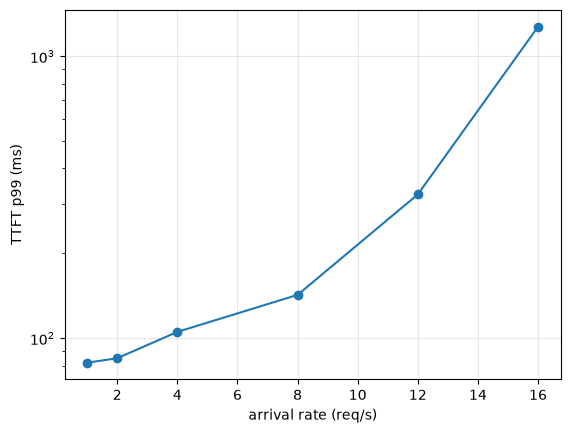

In [3]:
df = lsg.sweep("qps", [1, 2, 4, 8, 12, 16], num_requests=200)
plt.plot(df.index, df["TTFT p99 (ms)"], "o-")
plt.xlabel("arrival rate (req/s)"); plt.ylabel("TTFT p99 (ms)"); plt.yscale("log")
plt.grid(alpha=.3);

:::{admonition} Try it
:class: exercise
Change `device="a100"` to `device="h100"` above and rerun. What changes?
:::